# ¿Puede Starship lanzar 1.800 veces antes de 2036?

Google ha enviado su primera TPU al espacio como parte de **Project Suncatcher**, un proyecto que explora la posibilidad de construir centros de datos de inteligencia artificial en órbita.

La idea no depende únicamente de que un chip sobreviva a la radiación. Según el análisis citado por TechCrunch, reducir el precio del transporte hasta unos **200 dólares por kilogramo** exigiría que Starship colocara aproximadamente **370.000 toneladas** en órbita durante una década: alrededor de **1.800 lanzamientos**.

En este notebook comparo esa escala con el historial observable de Starship y construyo varios escenarios hasta 2035. El objetivo no es adivinar una cifra exacta, sino identificar qué tendría que ocurrir para que el proyecto pasara de demostrador tecnológico a infraestructura comercial.

## Fuentes y alcance

El análisis utiliza cuatro referencias principales:

- El artículo de **TechCrunch** publicado el 1 de octubre de 2026, incluida su corrección de 1.600 a **1.800 lanzamientos**.
- La explicación técnica de **Google Research** sobre Project Suncatcher.
- La actualización de Google del 24 de septiembre de 2026 sobre el primer ensayo orbital.
- El dataset de los 14 vuelos integrados de Starship ya utilizado en Nebula.

Las cifras futuras son hipótesis de escenario. Google no ha publicado un calendario de 1.800 misiones de Starship ni una previsión anual de lanzamientos. Por ello, el notebook separa los **hechos observados**, los **supuestos atribuidos a Google** y los **escenarios construidos aquí**.

## Preparación del análisis

Importo las librerías utilizadas habitualmente en los análisis de Nebula y mantengo el mismo estilo visual.

In [1]:
# importo las librerías necesarias
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# configuro el estilo general de las visualizaciones
sns.set_theme(
    style="whitegrid",
    palette="deep"
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

## El punto de partida: la cadencia real de Starship

Recupero el dataset del análisis anterior de Nebula. Cada fila representa un vuelo integrado de Starship entre abril de 2023 y septiembre de 2026.

El código admite dos ubicaciones de trabajo: ejecutar el notebook desde su propia carpeta o desde la raíz del repositorio.

In [2]:
# localizo el dataset histórico dentro del repositorio
candidatos = [
    Path("..") / "starship" / "starship_flights_1_14.csv",
    Path("starship") / "starship_flights_1_14.csv"
]

ruta_starship = next(
    (ruta for ruta in candidatos if ruta.exists()),
    None
)

if ruta_starship is None:
    raise FileNotFoundError(
        "No se encontró starship_flights_1_14.csv en el repositorio."
    )

# cargo las fechas de los vuelos integrados
vuelos = pd.read_csv(
    ruta_starship,
    parse_dates=["launch_date"]
)

print(f"dataset: {ruta_starship.resolve()}")
print(f"vuelos: {len(vuelos)}")
print(
    "periodo:",
    vuelos["launch_date"].min().date(),
    "—",
    vuelos["launch_date"].max().date()
)

dataset: C:\Users\rober\OneDrive\Documentos\proyectos_datos\_repos_nebula\starship\starship_flights_1_14.csv
vuelos: 14
periodo: 2023-04-20 — 2026-09-28


In [3]:
# cuento los vuelos integrados realizados cada año
cadencia_historica = (
    vuelos
    .assign(anio=vuelos["launch_date"].dt.year)
    .groupby("anio")
    .agg(
        vuelos_integrados=("flight_number", "count"),
        primer_vuelo=("launch_date", "min"),
        ultimo_vuelo=("launch_date", "max")
    )
    .reset_index()
)

# calculo el máximo observado y la media anual
maximo_historico = int(
    cadencia_historica["vuelos_integrados"].max()
)

media_historica = (
    cadencia_historica["vuelos_integrados"].mean()
)

display(cadencia_historica)

,anio,vuelos_integrados,primer_vuelo,ultimo_vuelo
0,2023,2,2023-04-20,2023-11-18
1,2024,4,2024-03-14,2024-11-19
2,2025,5,2025-01-16,2025-10-13
3,2026,3,2026-05-22,2026-09-28


### El récord anual observado es de cinco vuelos

Starship pasó de dos vuelos integrados en 2023 a cuatro en 2024 y cinco en 2025. En 2026 había realizado tres hasta el 28 de septiembre, fecha en la que alcanzó la órbita por primera vez.

Este histórico describe una campaña experimental, no una operación comercial madura. Aun así, ofrece una referencia útil: la media necesaria para la hipótesis de Google es **36 veces superior** al máximo anual observado hasta ahora.

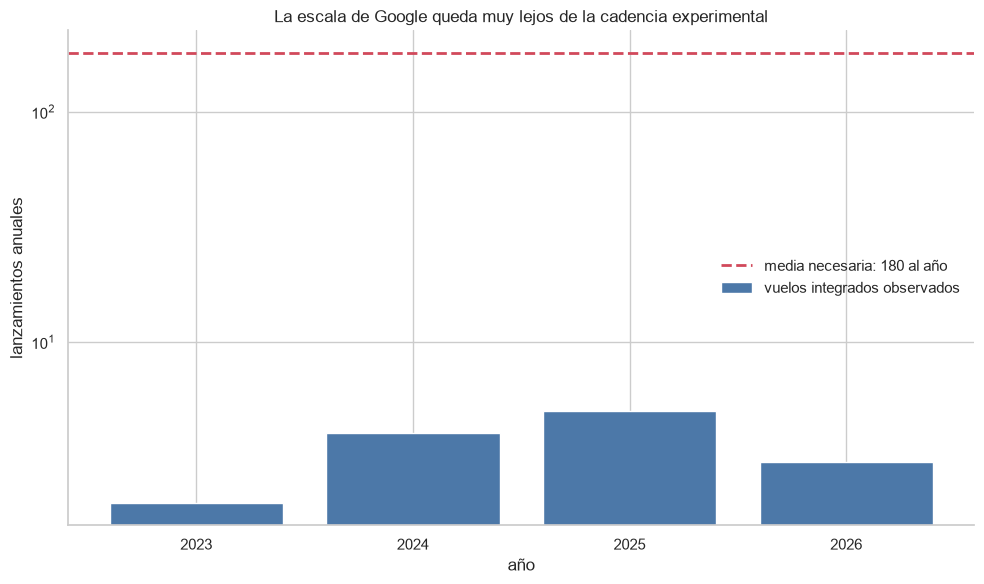

In [4]:
# comparo la cadencia histórica con la media exigida por el objetivo
media_objetivo = 180

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    cadencia_historica["anio"].astype(str),
    cadencia_historica["vuelos_integrados"],
    color="#4c78a8",
    label="vuelos integrados observados"
)

ax.axhline(
    media_objetivo,
    color="#d1495b",
    linestyle="--",
    linewidth=2,
    label="media necesaria: 180 al año"
)

ax.set(
    title="La escala de Google queda muy lejos de la cadencia experimental",
    xlabel="año",
    ylabel="lanzamientos anuales",
    yscale="log"
)

ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

## Traducir el titular a magnitudes comprobables

La estimación publicada combina cuatro cifras: una década, 370.000 toneladas acumuladas, 200 toneladas por misión y aproximadamente 1.800 lanzamientos.

Antes de proyectar la cadencia, compruebo cómo encajan entre sí.

In [5]:
# reúno los supuestos publicados
inicio = 2026
fin = 2035
anios = np.arange(inicio, fin + 1)

objetivo_lanzamientos = 1_800
objetivo_toneladas = 370_000
carga_maxima_t = 200
precio_objetivo_kg = 200

# calculo las magnitudes implícitas
numero_anios = len(anios)
media_anual_necesaria = objetivo_lanzamientos / numero_anios
lanzamientos_para_toneladas = int(
    np.ceil(objetivo_toneladas / carga_maxima_t)
)
carga_media_para_1800 = (
    objetivo_toneladas / objetivo_lanzamientos
)

metricas_objetivo = pd.DataFrame({
    "métrica": [
        "horizonte",
        "lanzamientos del titular",
        "media anual implícita",
        "toneladas acumuladas",
        "carga máxima supuesta por vuelo",
        "lanzamientos exactos para 370.000 t",
        "carga media necesaria con 1.800 vuelos",
        "precio objetivo de lanzamiento"
    ],
    "valor": [
        f"{numero_anios} años",
        f"{objetivo_lanzamientos:,}".replace(",", "."),
        f"{media_anual_necesaria:.0f} al año",
        f"{objetivo_toneladas:,} t".replace(",", "."),
        f"{carga_maxima_t} t",
        f"{lanzamientos_para_toneladas:,}".replace(",", "."),
        f"{carga_media_para_1800:.1f} t",
        f"{precio_objetivo_kg} $/kg"
    ]
})

display(metricas_objetivo.set_index("métrica"))

,valor
métrica,
horizonte,10 años
lanzamientos del titular,1.800
media anual implícita,180 al año
toneladas acumuladas,370.000 t
carga máxima supuesta por vuelo,200 t
lanzamientos exactos para 370.000 t,1.850
carga media necesaria con 1.800 vuelos,205.6 t
precio objetivo de lanzamiento,200 $/kg


### Los 1.800 lanzamientos son una aproximación

Si cada misión transportara exactamente 200 toneladas, 1.800 vuelos sumarían **360.000 toneladas**, 10.000 menos que el volumen citado. Alcanzar 370.000 toneladas exigiría 1.850 misiones o una carga media de 205,6 toneladas.

La diferencia no invalida el argumento de Google: las cifras son una estimación de orden de magnitud. Sí aconseja evitar una falsa precisión al convertirlas en predicción.

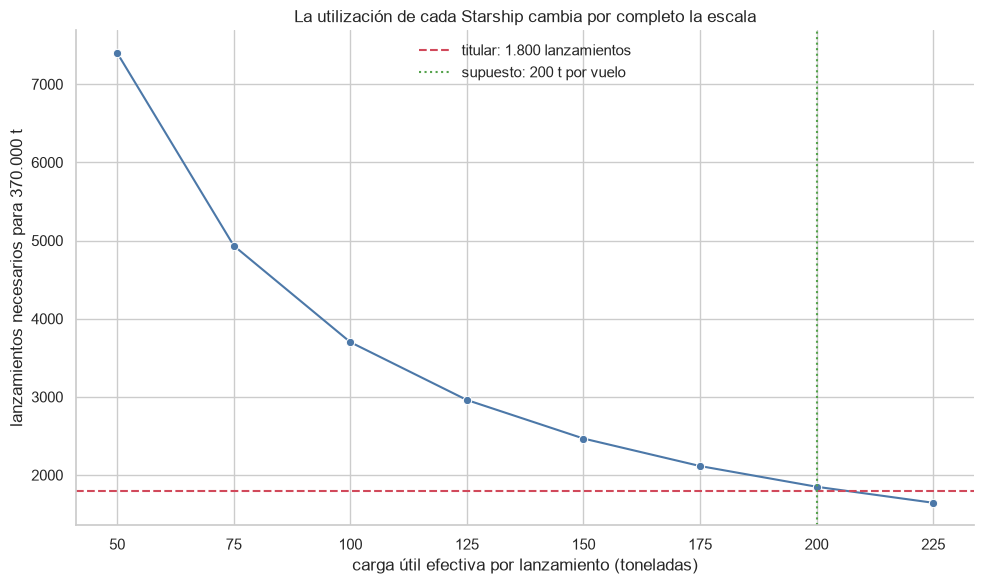

In [6]:
# calculo cuántos lanzamientos exige cada carga útil efectiva
cargas_efectivas = np.arange(50, 226, 25)

sensibilidad_carga = pd.DataFrame({
    "carga_efectiva_t": cargas_efectivas
})

sensibilidad_carga["lanzamientos_necesarios"] = np.ceil(
    objetivo_toneladas
    / sensibilidad_carga["carga_efectiva_t"]
).astype(int)

fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(
    data=sensibilidad_carga,
    x="carga_efectiva_t",
    y="lanzamientos_necesarios",
    marker="o",
    color="#4c78a8",
    ax=ax
)

ax.axhline(
    objetivo_lanzamientos,
    color="#d1495b",
    linestyle="--",
    label="titular: 1.800 lanzamientos"
)

ax.axvline(
    carga_maxima_t,
    color="#54a24b",
    linestyle=":",
    label="supuesto: 200 t por vuelo"
)

ax.set(
    title="La utilización de cada Starship cambia por completo la escala",
    xlabel="carga útil efectiva por lanzamiento (toneladas)",
    ylabel="lanzamientos necesarios para 370.000 t"
)

ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

## ¿Qué crecimiento anual permitiría llegar a 1.800 vuelos?

Una media de 180 lanzamientos anuales puede inducir a error porque Starship no comienza la década operando a ese ritmo. Si la trayectoria parte del récord observado de cinco vuelos, los últimos años tendrían que compensar el arranque lento.

Calculo la tasa de crecimiento constante que hace que la suma de los diez años alcance exactamente 1.800 lanzamientos. Es un **umbral matemático**, no una previsión industrial.

In [7]:
# defino la suma de una trayectoria con crecimiento compuesto
def lanzamientos_acumulados(tasa, inicial, periodos):
    return sum(
        inicial * (1 + tasa) ** indice
        for indice in range(periodos)
    )


# busco la tasa mediante bisección para no depender de scipy
def buscar_tasa_objetivo(
    objetivo,
    inicial,
    periodos,
    limite_inferior=0,
    limite_superior=2,
    iteraciones=100
):
    inferior = limite_inferior
    superior = limite_superior

    for _ in range(iteraciones):
        centro = (inferior + superior) / 2
        acumulado = lanzamientos_acumulados(
            centro,
            inicial,
            periodos
        )

        if acumulado < objetivo:
            inferior = centro
        else:
            superior = centro

    return (inferior + superior) / 2


tasa_umbral = buscar_tasa_objetivo(
    objetivo=objetivo_lanzamientos,
    inicial=maximo_historico,
    periodos=numero_anios
)

trayectoria_umbral = pd.DataFrame({
    "anio": anios,
    "lanzamientos": [
        maximo_historico * (1 + tasa_umbral) ** indice
        for indice in range(numero_anios)
    ]
})

trayectoria_umbral["lanzamientos_acumulados"] = (
    trayectoria_umbral["lanzamientos"].cumsum()
)

print(f"crecimiento anual constante: {tasa_umbral:.1%}")
print(
    "lanzamientos en 2035:",
    f"{trayectoria_umbral['lanzamientos'].iloc[-1]:.0f}"
)
print(
    "ritmo diario en 2035:",
    f"{trayectoria_umbral['lanzamientos'].iloc[-1] / 365:.2f}"
)

display(
    trayectoria_umbral.round(1).set_index("anio")
)

crecimiento anual constante: 75.1%
lanzamientos en 2035: 775
ritmo diario en 2035: 2.12


,lanzamientos,lanzamientos_acumulados
anio,,
2026,5.0,5.0
2027,8.8,13.8
2028,15.3,29.1
2029,26.9,56.0
2030,47.0,103.0
2031,82.4,185.4
2032,144.3,329.7
2033,252.7,582.4
2034,442.6,1024.9


### El objetivo no requiere 180 vuelos en 2035, sino más de dos al día

Partiendo de cinco lanzamientos, Starship tendría que aumentar su cadencia aproximadamente un **75% cada año durante una década**. La trayectoria terminaría cerca de **775 vuelos en 2035**, algo más de dos diarios.

Esto revela el verdadero cuello de botella del titular. No basta con demostrar que Starship puede transportar 200 toneladas: el sistema completo tendría que producir vehículos, motores, combustible, plataformas, licencias y operaciones a una escala comparable con la aviación comercial.

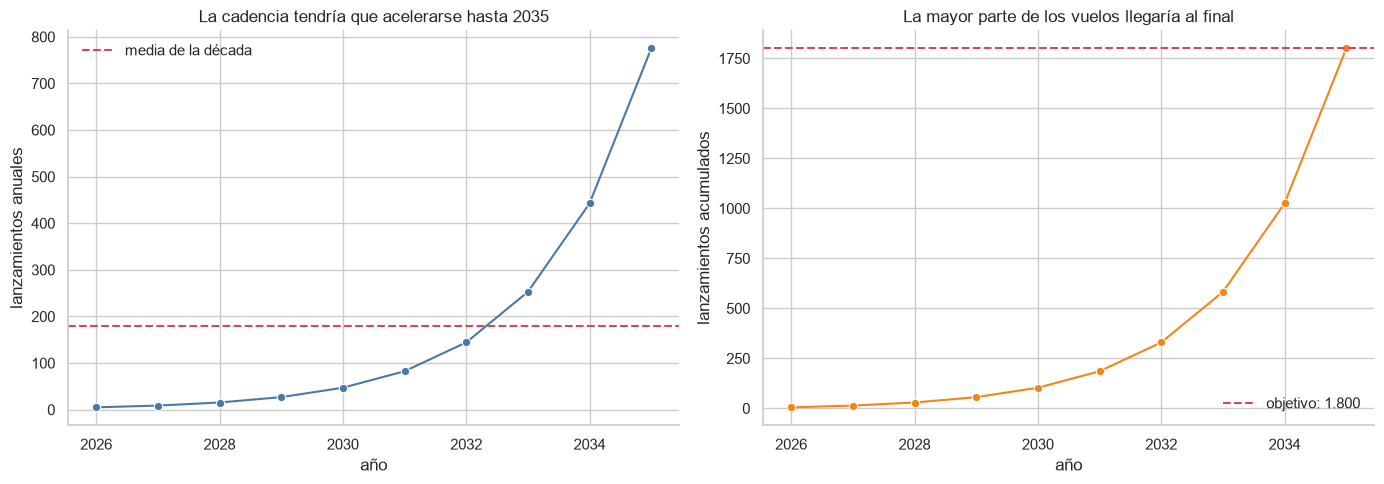

In [8]:
# represento la trayectoria anual y la acumulación exigida
fig, ejes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(
    data=trayectoria_umbral,
    x="anio",
    y="lanzamientos",
    marker="o",
    color="#4c78a8",
    ax=ejes[0]
)

ejes[0].axhline(
    media_objetivo,
    color="#d1495b",
    linestyle="--",
    label="media de la década"
)

ejes[0].set(
    title="La cadencia tendría que acelerarse hasta 2035",
    xlabel="año",
    ylabel="lanzamientos anuales"
)
ejes[0].legend(frameon=False)

sns.lineplot(
    data=trayectoria_umbral,
    x="anio",
    y="lanzamientos_acumulados",
    marker="o",
    color="#f58518",
    ax=ejes[1]
)

ejes[1].axhline(
    objetivo_lanzamientos,
    color="#d1495b",
    linestyle="--",
    label="objetivo: 1.800"
)

ejes[1].set(
    title="La mayor parte de los vuelos llegaría al final",
    xlabel="año",
    ylabel="lanzamientos acumulados"
)
ejes[1].legend(frameon=False)

for ax in ejes:
    ax.set_xticks(anios[::2])

sns.despine()
plt.tight_layout()
plt.show()

## Cuatro escenarios de cadencia

Construyo cuatro trayectorias para observar qué combinaciones de crecimiento y capacidad máxima podrían acercarse al objetivo:

- **Conservador:** crecimiento anual del 40% y techo de 120 vuelos.
- **Central:** crecimiento del 60% y techo de 250 vuelos.
- **Umbral matemático:** la tasa exacta necesaria, sin imponer un techo industrial.
- **Acelerado:** crecimiento del 90% y techo de 500 vuelos anuales.

Los porcentajes no proceden de una predicción de SpaceX. Son pruebas de sensibilidad diseñadas para mostrar cuán exigente es la meta.

In [9]:
# defino las hipótesis de los cuatro escenarios
escenarios = pd.DataFrame([
    {
        "escenario": "conservador",
        "crecimiento": 0.40,
        "techo_anual": 120
    },
    {
        "escenario": "central",
        "crecimiento": 0.60,
        "techo_anual": 250
    },
    {
        "escenario": "umbral matemático",
        "crecimiento": tasa_umbral,
        "techo_anual": np.inf
    },
    {
        "escenario": "acelerado",
        "crecimiento": 0.90,
        "techo_anual": 500
    }
])


def construir_escenario(nombre, crecimiento, techo):
    lanzamientos = [
        min(
            maximo_historico * (1 + crecimiento) ** indice,
            techo
        )
        for indice in range(numero_anios)
    ]

    tabla = pd.DataFrame({
        "anio": anios,
        "escenario": nombre,
        "lanzamientos": lanzamientos
    })

    tabla["lanzamientos_acumulados"] = (
        tabla["lanzamientos"].cumsum()
    )

    return tabla


proyecciones = pd.concat(
    [
        construir_escenario(
            fila["escenario"],
            fila["crecimiento"],
            fila["techo_anual"]
        )
        for _, fila in escenarios.iterrows()
    ],
    ignore_index=True
)

resumen_escenarios = (
    proyecciones
    .groupby("escenario", sort=False)
    .agg(
        lanzamientos_decada=("lanzamientos", "sum"),
        lanzamientos_2035=("lanzamientos", "last")
    )
)

resumen_escenarios["porcentaje_objetivo"] = (
    resumen_escenarios["lanzamientos_decada"]
    .div(objetivo_lanzamientos)
    .mul(100)
)

resumen_escenarios["cumple_1800"] = (
    resumen_escenarios["lanzamientos_decada"]
    .ge(objetivo_lanzamientos - 1e-6)
)

display(resumen_escenarios.round(1))

,lanzamientos_decada,lanzamientos_2035,porcentaje_objetivo,cumple_1800
escenario,,,,
conservador,349.1,103.3,19.4,False
central,814.3,250.0,45.2,False
umbral matemático,1800.0,775.1,100.0,True
acelerado,1938.0,500.0,107.7,True


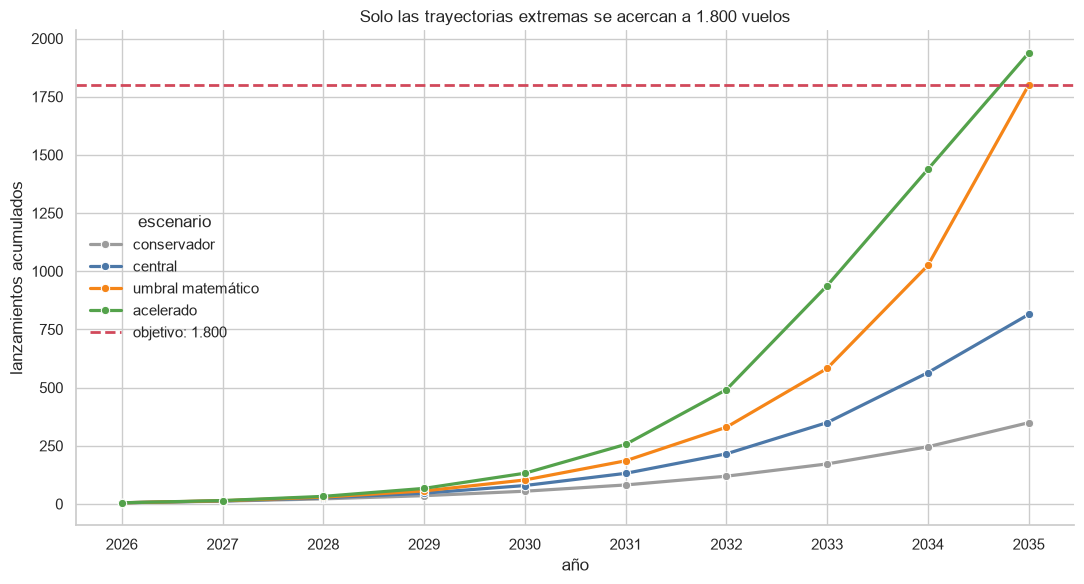

In [10]:
# comparo la acumulación de los escenarios
colores_escenario = {
    "conservador": "#9c9c9c",
    "central": "#4c78a8",
    "umbral matemático": "#f58518",
    "acelerado": "#54a24b"
}

fig, ax = plt.subplots(figsize=(11, 6))

sns.lineplot(
    data=proyecciones,
    x="anio",
    y="lanzamientos_acumulados",
    hue="escenario",
    palette=colores_escenario,
    marker="o",
    linewidth=2.3,
    ax=ax
)

ax.axhline(
    objetivo_lanzamientos,
    color="#d1495b",
    linestyle="--",
    linewidth=2,
    label="objetivo: 1.800"
)

ax.set(
    title="Solo las trayectorias extremas se acercan a 1.800 vuelos",
    xlabel="año",
    ylabel="lanzamientos acumulados",
    xticks=anios
)

ax.legend(title="escenario", frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

### El escenario central no llega ni a la mitad

Incluso aumentando la cadencia un 60% anual y alcanzando un techo de 250 misiones, la década terminaría con alrededor de **800 lanzamientos**. El objetivo solo aparece cuando la actividad crece a tasas excepcionales durante casi todo el periodo y supera varios centenares de vuelos anuales.

La conclusión no es que 1.800 lanzamientos sean físicamente imposibles, sino que representan una **transformación industrial** mucho mayor que la transición técnica ya observada entre el primer vuelo y la inserción orbital.

## Sensibilidad del precio de lanzamiento

Google sitúa el punto de competitividad cerca de 200 dólares por kilogramo. Como no existe un precio comercial verificable de Starship en 2026, evito inventar una cifra base y planteo una matriz de sensibilidad.

La tabla responde a una pregunta condicional: si el coste inicial estuviera entre 1.000 y 3.000 dólares por kilogramo, ¿cuántos años tardaría en bajar de 200 con reducciones anuales sostenidas del 15%, 20% o 25%?

In [11]:
# construyo una sensibilidad sin asumir un precio actual concreto
precios_iniciales = [1_000, 1_500, 2_000, 3_000]
reducciones_anuales = [0.15, 0.20, 0.25]

resultados_coste = []

for precio_inicial in precios_iniciales:
    for reduccion in reducciones_anuales:
        if precio_inicial <= precio_objetivo_kg:
            anios_necesarios = 0
        else:
            anios_necesarios = int(
                np.ceil(
                    np.log(precio_objetivo_kg / precio_inicial)
                    / np.log(1 - reduccion)
                )
            )

        resultados_coste.append({
            "precio_inicial_kg": precio_inicial,
            "reduccion_anual": f"{reduccion:.0%}",
            "anios_hasta_200": anios_necesarios,
            "llegaria_en_2035": anios_necesarios <= 9
        })

sensibilidad_coste = pd.DataFrame(resultados_coste)

matriz_coste = sensibilidad_coste.pivot(
    index="precio_inicial_kg",
    columns="reduccion_anual",
    values="anios_hasta_200"
)

display(
    matriz_coste.rename_axis(
        index="precio inicial ($/kg)",
        columns="reducción anual"
    )
)

reducción anual,15%,20%,25%
precio inicial ($/kg),,,
1000,10,8,6
1500,13,10,8
2000,15,11,9
3000,17,13,10


### Una curva de aprendizaje necesita repetición, no solo capacidad

Con un coste hipotético de 2.000 dólares por kilogramo, una reducción anual del 20% necesitaría unos once años para cruzar el umbral de 200. Una caída del 25% lo conseguiría en ocho.

El precio y la cadencia no son variables independientes. La producción repetida puede reducir costes, pero una caída del precio también es necesaria para generar suficiente demanda. Project Suncatcher depende de que ese círculo se vuelva virtuoso sin que la fiabilidad, la regulación o la infraestructura terrestre frenen la escala.

## Lo que el modelo no captura: cuatro puertas técnicas

La cadencia de Starship es una condición necesaria, pero no suficiente. Antes de desplegar un centro de datos orbital, Google debe demostrar al menos cuatro capacidades:

1. **Supervivencia del hardware.** Las TPU deben soportar vibraciones, radiación y ciclos térmicos durante años.
2. **Refrigeración en vacío.** Sin aire, el calor debe disiparse mediante conducción y grandes radiadores.
3. **Red óptica entre satélites.** Los futuros nodos necesitan conexiones de decenas de terabits por segundo y una puntería extremadamente precisa.
4. **Operación de formaciones compactas.** La propuesta de 81 satélites exige mantener vehículos separados por centenares de metros alrededor de los 650 kilómetros de altitud.

El primer satélite prueba principalmente la primera puerta. Google prevé probar enlaces entre dos satélites en 2027; todavía no existe una constelación operativa equivalente a un centro de datos.

In [12]:
# resumo el estado público de las principales condiciones
puertas_tecnicas = pd.DataFrame([
    {
        "condición": "TPU en órbita",
        "estado en octubre de 2026": "primer prototipo lanzado",
        "próxima evidencia": "operación y errores en vuelo"
    },
    {
        "condición": "refrigeración en vacío",
        "estado en octubre de 2026": "ensayos terrestres y primer vuelo",
        "próxima evidencia": "rendimiento térmico continuado"
    },
    {
        "condición": "enlace óptico distribuido",
        "estado en octubre de 2026": "demostrador terrestre de 1,6 Tbps",
        "próxima evidencia": "dos satélites enlazados en 2027"
    },
    {
        "condición": "formación de 81 satélites",
        "estado en octubre de 2026": "modelada, no desplegada",
        "próxima evidencia": "control orbital multivehículo"
    },
    {
        "condición": "Starship comercial repetible",
        "estado en octubre de 2026": "primera inserción orbital",
        "próxima evidencia": "reutilización y cadencia sostenida"
    },
    {
        "condición": "coste inferior a 200 $/kg",
        "estado en octubre de 2026": "objetivo, no precio observado",
        "próxima evidencia": "contratos y costes operativos"
    }
])

display(puertas_tecnicas.set_index("condición"))

,estado en octubre de 2026,próxima evidencia
condición,,
TPU en órbita,primer prototipo lanzado,operación y errores en vuelo
refrigeración en vacío,ensayos terrestres y primer vuelo,rendimiento térmico continuado
enlace óptico distribuido,"demostrador terrestre de 1,6 Tbps",dos satélites enlazados en 2027
formación de 81 satélites,"modelada, no desplegada",control orbital multivehículo
Starship comercial repetible,primera inserción orbital,reutilización y cadencia sostenida
coste inferior a 200 $/kg,"objetivo, no precio observado",contratos y costes operativos


## Conclusiones

El primer ensayo orbital de una TPU convierte Project Suncatcher en algo más que una presentación conceptual, pero los datos todavía apoyan una lectura prudente:

1. **El salto industrial domina la predicción.** Starship ha alcanzado un máximo de cinco vuelos integrados en un año. La hipótesis de 1.800 misiones equivale a una media de 180 anuales.

2. **La media oculta una aceleración mucho mayor.** Si la década comienza en cinco vuelos, llegar al total exige crecer cerca de un 75% anual y terminar 2035 con más de dos lanzamientos diarios.

3. **La carga útil importa tanto como la cadencia.** A 200 toneladas por vuelo harían falta 1.850 lanzamientos para transportar exactamente 370.000 toneladas. Una utilización efectiva de 100 toneladas duplicaría la necesidad.

4. **El escenario central queda lejos.** Incluso con un crecimiento anual del 60% y capacidad para 250 vuelos al año, el total no alcanza la mitad del objetivo publicado.

5. **La tecnología avanza por etapas.** Es razonable esperar nuevos demostradores y pequeños clústeres durante los próximos años. Un centro de datos orbital competitivo antes de 2036 requiere, además, resolver refrigeración, comunicaciones, fiabilidad, regulación y mantenimiento.

### Predicción editorial

**Antes de 2036 probablemente existirán clústeres orbitales experimentales capaces de ejecutar cargas especializadas de IA, pero no una infraestructura que compita de forma general con los grandes centros de datos terrestres.**

El escenario cambiaría si Starship demostrara simultáneamente reutilización rápida, más de cien vuelos anuales y costes verificables próximos a 200 dólares por kilogramo. Esos tres indicadores serán más informativos que cualquier anuncio aislado.

## Limitaciones

- El histórico contiene únicamente 14 vuelos integrados y no permite entrenar un modelo predictivo fiable.
- Los vuelos experimentales no son directamente comparables con una futura operación comercial.
- Los escenarios mantienen tasas de crecimiento simplificadas y no modelan accidentes, licencias, meteorología, plataformas ni capacidad de producción.
- La carga de 200 toneladas es un supuesto futuro; la carga útil efectiva puede ser menor y depender de la órbita.
- El objetivo de 370.000 toneladas y los 1.800 lanzamientos son estimaciones redondeadas, no un plan operativo publicado.
- La sensibilidad del precio utiliza puntos iniciales hipotéticos porque Starship no dispone de una tarifa comercial verificable en 2026.
- El análisis no calcula el coste de fabricar, mantener y reemplazar los satélites ni el impacto ambiental de la campaña de lanzamientos.

Por estas razones, los resultados deben leerse como una prueba de plausibilidad y no como una probabilidad estadística de éxito.

## Fuentes

- TechCrunch (1 de octubre de 2026): [Google thinks SpaceX’s Starship has to launch 1,800 times before space data centers get off the ground](https://techcrunch.com/2026/10/01/google-thinks-spacexs-starship-has-to-launch-1600-times-before-space-data-centers-get-off-the-ground/)
- Google Research (4 de noviembre de 2025): [Exploring a space-based, scalable AI infrastructure system design](https://research.google/blog/exploring-a-space-based-scalable-ai-infrastructure-system-design/)
- Google (24 de septiembre de 2026): [Behind Project Suncatcher, our moonshot to put AI in space](https://blog.google/innovation-and-ai/models-and-research/google-research/google-project-suncatcher-facts/)
- Nebula: `starship/starship_flights_1_14.csv`

**Nota editorial:** TechCrunch corrigió el titular de 1.600 a 1.800 lanzamientos. La dirección web conserva la cifra antigua.